## Download the data
- In normal company work, you will need to get data from various sources yourself using authorization and various other tools.
- But here, you may extract the housing.csv from housing.tgz at my github.

In [16]:
from pathlib import Path
import tarfile
import pandas as pd
import urllib.request
def load_housing_data():
    tar_path=Path("datasets/housing.tgz")
    if not tar_path.is_file():
        Path("datasets").mkdir(parents=True,exist_ok=True)
        url='https://github.com/ageron/data/raw/main/housing.tgz'
        urllib.request.urlretrieve(url,Path(tar_path))
        with tarfile.open(tar_path) as housing_path:
            housing_path.extractall(path='datasets')
    return pd.read_csv(Path('datasets/housing/housing.csv'))
    
housing = load_housing_data()
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


### What happened above ?
- I created a function to check if data is already in my device. if not, then I extract tgz file from github.
- after fetching from github, I extract all the files from the compressed .tgz folder.
- Then load the housing data. 

## Take a quick look at the data
- Use .head(), .info(), .describe(), etc methods to study the data first.
- See if all values are non-null or are there some null values.

In [17]:
print(housing.head())

print(f"\n\n\n\nDescription of data\n")
print(housing.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  




Description of data

          longitude      latitude  housing_median_

#### Object in ocean_proximity
- Every column except ocean proximity is float.
- Since you got data from csv, it means the object is nothing but string.
- Let's see the unique objects and their counts.

In [18]:
print(housing['ocean_proximity'].unique())

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [20]:
print(housing['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


*Another way to analyse data columns is to plot histograms*

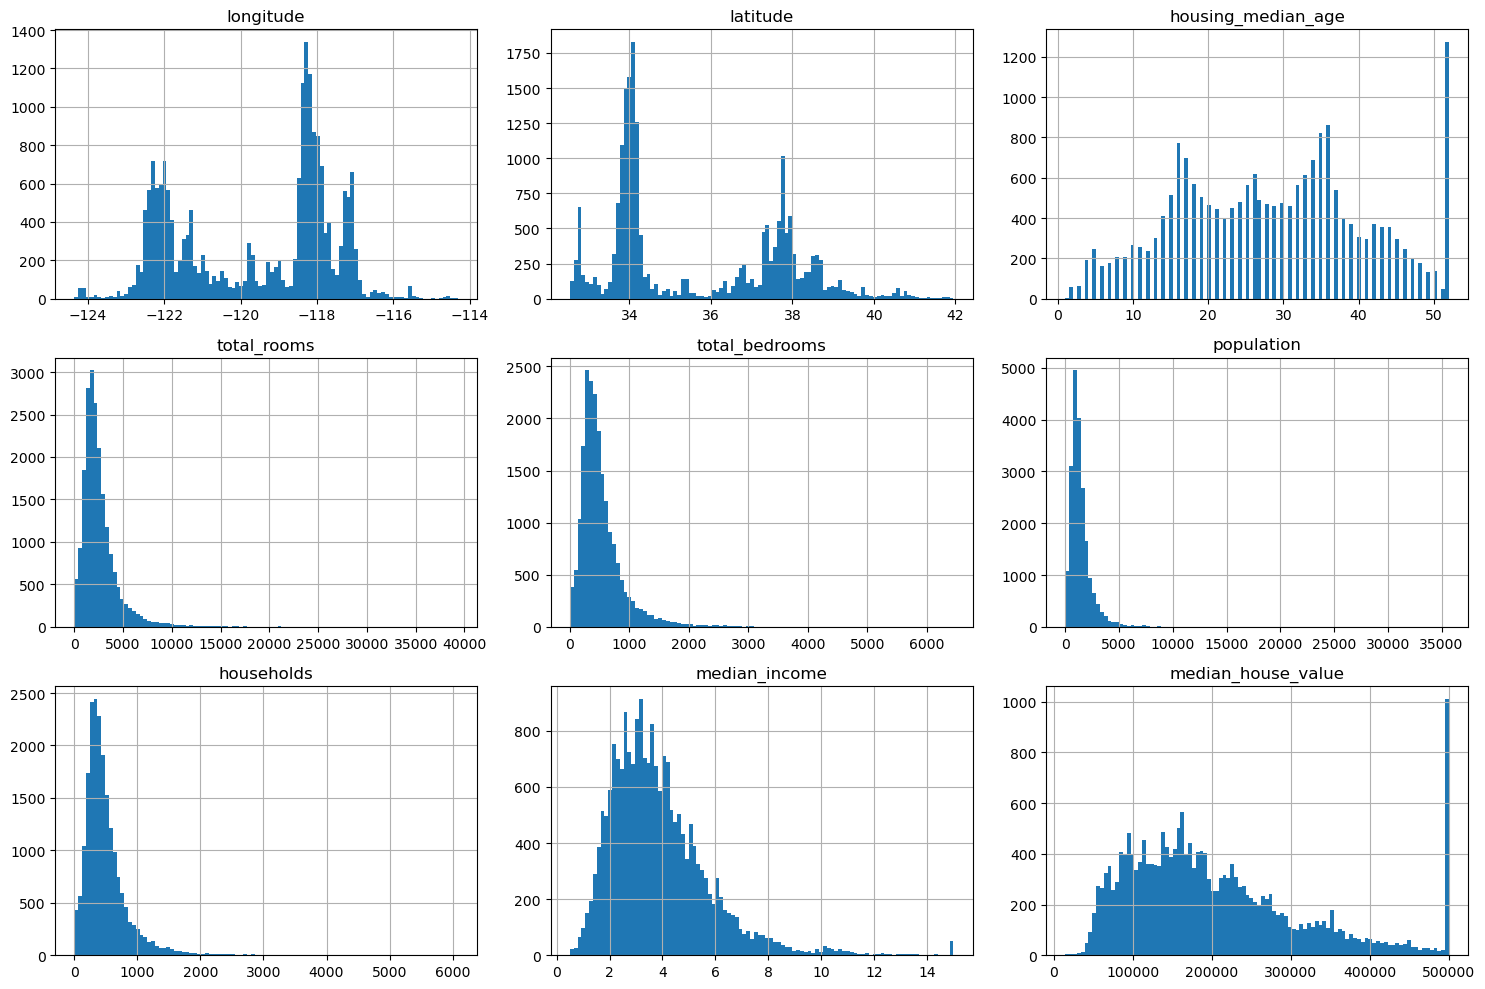

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
housing.hist(bins=100,figsize=(15,10))
plt.tight_layout()
plt.show()

In [28]:
for a in housing.unique():
    if a=='ocean_proximity':
        continue;
    housing[a].plot(kind='kde',figsize=(15,10))
    plt.tight_layout()
    plt.show()

AttributeError: 'DataFrame' object has no attribute 'unique'